# ARIMA Gold Price Forecast
Based on `arima_model.py`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


In [3]:
# Load the data
try:
    raw_data = pd.read_csv('GoldPrices.csv')
except FileNotFoundError:
    print("Error: The file 'GoldPrices.csv' was not found.")
    raise SystemExit


In [4]:
# Specify the relevant features
relevant_features = ['Date', 'Close']

# Convert 'Date' to datetime format if it's not already
raw_data['Date'] = pd.to_datetime(raw_data['Date'])

# Filter the data for the relevant features
data = raw_data[relevant_features]


In [5]:
# Split the data to train data and test data
split_index = int(len(data) * 0.95)
df_train = data.iloc[:split_index]
df_test = data.iloc[split_index:]


In [6]:
# Perform Augmented Dickey-Fuller test for stationarity
result = adfuller(df_train['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# First differencing
data_diff = df_train['Close'].diff().dropna()

# Recheck for stationarity after differencing
result = adfuller(data_diff)
print('ADF Statistic after differencing:', result[0])
print('p-value after differencing:', result[1])

stationary_data = data_diff


ADF Statistic: -1.6837412766686495
p-value: 0.4395083272639699
ADF Statistic after differencing: -30.347447234725532
p-value after differencing: 0.0


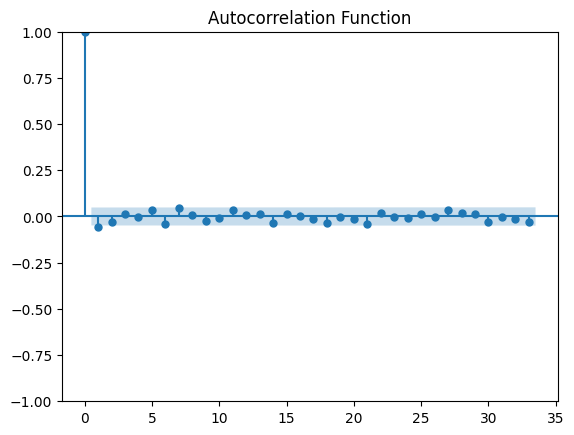

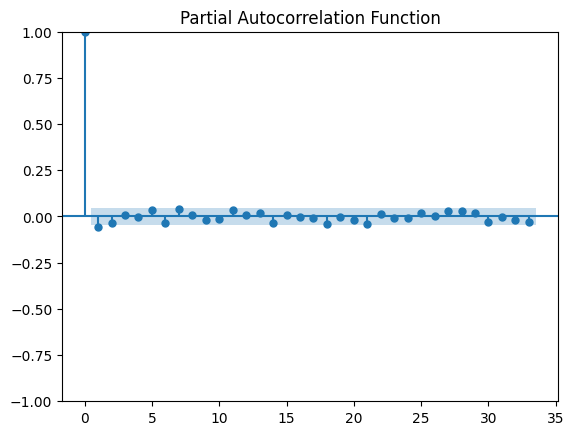

In [7]:
# Plot ACF and PACF to determine p and q
plot_acf(stationary_data, title='Autocorrelation Function')
plot_pacf(stationary_data, title='Partial Autocorrelation Function')
plt.show()


In [8]:
# Model parameters determined by inspecting ACF and PACF
p = 1  # lag order
d = 1  # differencing order
q = 1  # moving average order

# Define the ARIMA model
model = ARIMA(df_train['Close'], order=(p, d, q))

try:
    model_fit = model.fit()
except Exception as e:
    print(f"Model fitting failed: {e}")
    raise SystemExit


In [9]:
# Summary of the model
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1632
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2711.513
Date:                Sun, 29 Mar 2026   AIC                           5429.026
Time:                        18:20:47   BIC                           5445.217
Sample:                             0   HQIC                          5435.032
                               - 1632                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2654      0.322      0.825      0.409      -0.365       0.896
ma.L1         -0.3281      0.314     -1.045      0.296      -0.944       0.287
sigma2         1.6275      0.022     72.500      0.000       1.584       1.672
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              9368.97
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.27   Skew:                            -0.67
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [10]:
# Forecast the future values
forecast_steps = len(df_test['Close'])
forecast = model_fit.forecast(steps=forecast_steps)
forecast

1632    114.056328
1633    114.028807
1634    114.021502
1635    114.019563
1636    114.019048
           ...    
1713    114.018862
1714    114.018862
1715    114.018862
1716    114.018862
1717    114.018862
Name: predicted_mean, Length: 86, dtype: float64

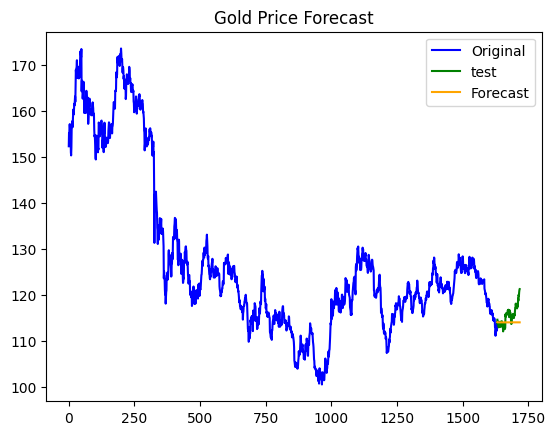

In [11]:
# Plot the original data and the forecast
plt.figure()
plt.plot(df_train['Close'], label='Original', color='blue')
plt.plot(range(len(df_train['Close']), len(df_train['Close']) + forecast_steps), df_test['Close'], label='test', color='green')
plt.plot(range(len(df_train['Close']), len(df_train['Close']) + forecast_steps), forecast, label='Forecast', color='orange')
plt.legend()
plt.title('Gold Price Forecast')
plt.show()


In [12]:
# Calculate error metrics
mae = mean_absolute_error(df_test['Close'], forecast)
mse = mean_squared_error(df_test['Close'], forecast)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 1.940728281288092
Mean Squared Error (MSE): 6.376480215024802
Root Mean Squared Error (RMSE): 2.525169343831182
